In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\TAKI-
[nltk_data]     KUN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\TAKI-
[nltk_data]     KUN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\TAKI-
[nltk_data]     KUN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [59]:
df = pd.read_csv('Reviews.csv')

In [60]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [61]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [62]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [63]:
df['ProductId'] = df['ProductId'].astype(str)
df['UserId'] = df['UserId'].astype(str)
df['ProfileName'] = df['ProfileName'].astype(str)
df['Summary'] = df['Summary'].astype(str)
df['Text'] = df['Text'].astype(str)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB


In [64]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [65]:
df = df.dropna()

In [66]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [67]:
df.duplicated().sum()

0

In [68]:
df = df[df['HelpfulnessNumerator'] <= df['HelpfulnessDenominator']]
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


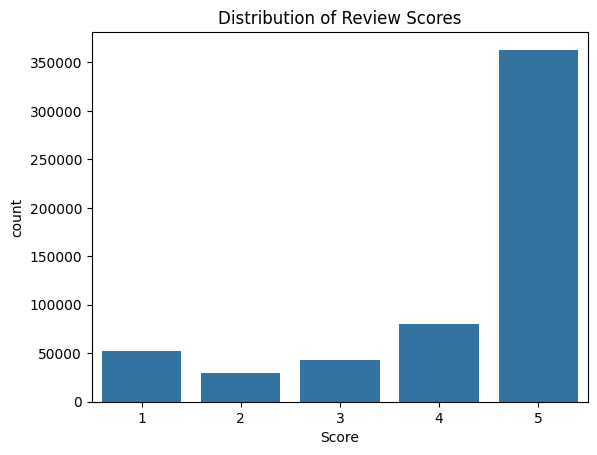

In [69]:
sns.countplot(x="Score", data=df)
plt.title("Distribution of Review Scores")
plt.show()

# five star reviews dominate

In [70]:
def sentiment(score):

    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(sentiment)
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive
...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive


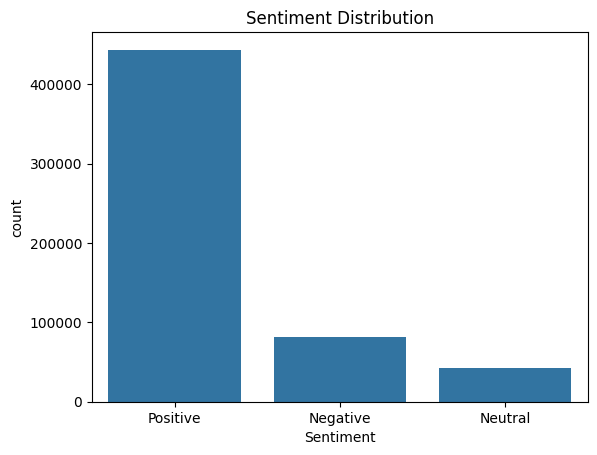

In [71]:
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

In [72]:
print(df['Sentiment'].value_counts())
print(df['Sentiment'].value_counts(normalize=True).mul(100).round(1))

# Separate all three classes
df_positive = df[df['Sentiment'] == "Positive"]
df_negative = df[df['Sentiment'] == "Negative"]
df_neutral  = df[df['Sentiment'] == "Neutral"]

# Undersample all classes to match the minority class size
df_positive_under = df_positive.sample(n=len(df_neutral), random_state=42)
df_negative_under = df_negative.sample(n=len(df_neutral), random_state=42)
df_neutral_under  = df_neutral.sample(n=len(df_neutral),  random_state=42)

# Combine and shuffle
df_balanced = pd.concat([df_positive_under, df_negative_under, df_neutral_under])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify
print("\nAfter balancing:")
print(df_balanced['Sentiment'].value_counts())
print(df_balanced['Sentiment'].value_counts(normalize=True).mul(100).round(1))

Sentiment
Positive    443754
Negative     82007
Neutral      42638
Name: count, dtype: int64
Sentiment
Positive    78.1
Negative    14.4
Neutral      7.5
Name: proportion, dtype: float64

After balancing:
Sentiment
Positive    42638
Neutral     42638
Negative    42638
Name: count, dtype: int64
Sentiment
Positive    33.3
Neutral     33.3
Negative    33.3
Name: proportion, dtype: float64


In [73]:
df=df_balanced.copy()
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive
...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive


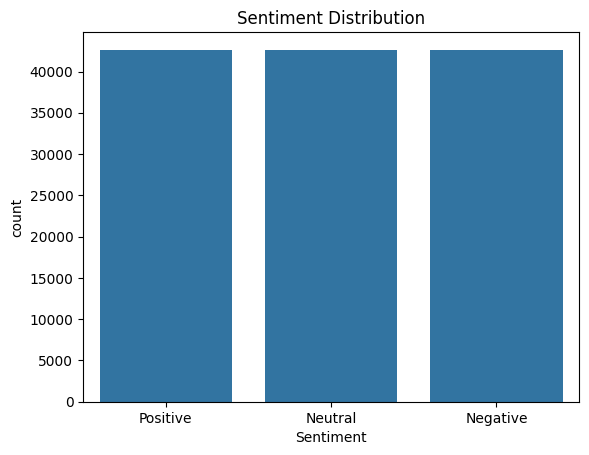

In [74]:
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

In [75]:
df["review"] = df["Summary"] + " " + df["Text"]
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr..."
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner..."
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...
...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...


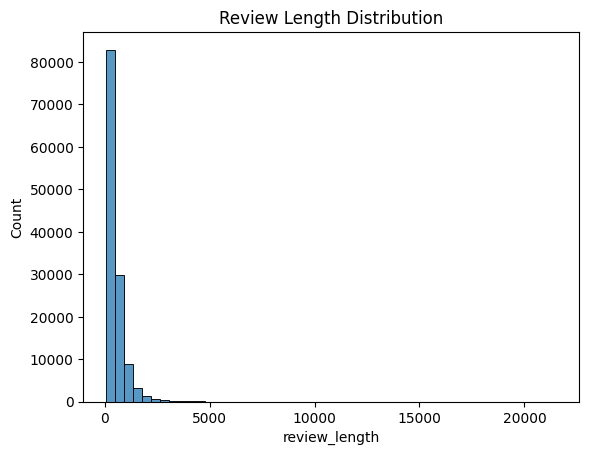

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248


In [76]:
df["review_length"] = df["review"].apply(len)

sns.histplot(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.show()
df

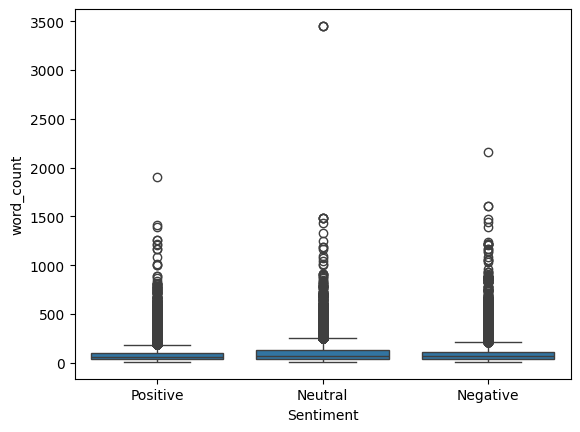

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235,45
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521,98
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86,16
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974,178
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150,27
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122,23
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217,42
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248,47


In [77]:
df["word_count"] = df["review"].apply(lambda x: len(str(x).split()))
sns.boxplot(x="Sentiment", y="word_count", data=df)
plt.show()
df

In [78]:
# Text PreProcessing
def remove_html(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)
df["clean_text"] = df["review"].apply(remove_html)

In [79]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235,45,Excellent coffee I purchased this for work sin...
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521,98,"NOT GLUTEN FREE These cookies may be ""wheat fr..."
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86,16,best syrup Fox's u-bet chocolate syrup is grea...
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974,178,"Pleasant, average conditioner This conditioner..."
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482,92,Oh man it's tasty We gave a bag of this a try-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150,27,broken pieces I love cheez-its. These were go...
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122,23,Not what I expected. The popped corn was very ...
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217,42,Great Food Love the price and the number of bo...
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248,47,Love It!!! I'm a true fan of Coconut!!! This p...


In [80]:
def remove_punctuation(text):
    return re.sub('[^a-zA-Z]', ' ', text)

df["clean_text"] = df["clean_text"].apply(remove_punctuation)
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235,45,Excellent coffee I purchased this for work sin...
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521,98,NOT GLUTEN FREE These cookies may be wheat fr...
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86,16,best syrup Fox s u bet chocolate syrup is grea...
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974,178,Pleasant average conditioner This conditioner...
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482,92,Oh man it s tasty We gave a bag of this a try ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150,27,broken pieces I love cheez its These were go...
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122,23,Not what I expected The popped corn was very ...
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217,42,Great Food Love the price and the number of bo...
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248,47,Love It I m a true fan of Coconut This p...


In [81]:
#covert to lower case
df["clean_text"] = df["clean_text"].str.lower()
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235,45,excellent coffee i purchased this for work sin...
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521,98,not gluten free these cookies may be wheat fr...
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86,16,best syrup fox s u bet chocolate syrup is grea...
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974,178,pleasant average conditioner this conditioner...
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482,92,oh man it s tasty we gave a bag of this a try ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150,27,broken pieces i love cheez its these were go...
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122,23,not what i expected the popped corn was very ...
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217,42,great food love the price and the number of bo...
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248,47,love it i m a true fan of coconut this p...


In [82]:
#Tokenisation (making 1 words as 1 element of list or 1D array)
df["tokens"] = df["clean_text"].apply(word_tokenize)
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235,45,excellent coffee i purchased this for work sin...,"[excellent, coffee, i, purchased, this, for, w..."
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521,98,not gluten free these cookies may be wheat fr...,"[not, gluten, free, these, cookies, may, be, w..."
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86,16,best syrup fox s u bet chocolate syrup is grea...,"[best, syrup, fox, s, u, bet, chocolate, syrup..."
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974,178,pleasant average conditioner this conditioner...,"[pleasant, average, conditioner, this, conditi..."
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482,92,oh man it s tasty we gave a bag of this a try ...,"[oh, man, it, s, tasty, we, gave, a, bag, of, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150,27,broken pieces i love cheez its these were go...,"[broken, pieces, i, love, cheez, its, these, w..."
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122,23,not what i expected the popped corn was very ...,"[not, what, i, expected, the, popped, corn, wa..."
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217,42,great food love the price and the number of bo...,"[great, food, love, the, price, and, the, numb..."
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248,47,love it i m a true fan of coconut this p...,"[love, it, i, m, a, true, fan, of, coconut, th..."


In [83]:
#stopwords removal (removing un necessary words - verbs, articles etc)
stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(lambda words: [w for w in words if w not in stop_words])

In [84]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235,45,excellent coffee i purchased this for work sin...,"[excellent, coffee, purchased, work, since, go..."
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521,98,not gluten free these cookies may be wheat fr...,"[gluten, free, cookies, may, wheat, free, made..."
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86,16,best syrup fox s u bet chocolate syrup is grea...,"[best, syrup, fox, u, bet, chocolate, syrup, g..."
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974,178,pleasant average conditioner this conditioner...,"[pleasant, average, conditioner, conditioner, ..."
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482,92,oh man it s tasty we gave a bag of this a try ...,"[oh, man, tasty, gave, bag, try, resulted, ent..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150,27,broken pieces i love cheez its these were go...,"[broken, pieces, love, cheez, good, fresh, ope..."
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122,23,not what i expected the popped corn was very ...,"[expected, popped, corn, small, seem, lot, cor..."
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217,42,great food love the price and the number of bo...,"[great, food, love, price, number, boxes, get,..."
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248,47,love it i m a true fan of coconut this p...,"[love, true, fan, coconut, product, great, sme..."


In [85]:
lemmatizer = WordNetLemmatizer()
df["tokens"] = df["tokens"].apply(lambda words: [lemmatizer.lemmatize(w) for w in words])
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235,45,excellent coffee i purchased this for work sin...,"[excellent, coffee, purchased, work, since, go..."
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521,98,not gluten free these cookies may be wheat fr...,"[gluten, free, cooky, may, wheat, free, made, ..."
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86,16,best syrup fox s u bet chocolate syrup is grea...,"[best, syrup, fox, u, bet, chocolate, syrup, g..."
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974,178,pleasant average conditioner this conditioner...,"[pleasant, average, conditioner, conditioner, ..."
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482,92,oh man it s tasty we gave a bag of this a try ...,"[oh, man, tasty, gave, bag, try, resulted, ent..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150,27,broken pieces i love cheez its these were go...,"[broken, piece, love, cheez, good, fresh, open..."
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122,23,not what i expected the popped corn was very ...,"[expected, popped, corn, small, seem, lot, cor..."
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217,42,great food love the price and the number of bo...,"[great, food, love, price, number, box, get, b..."
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248,47,love it i m a true fan of coconut this p...,"[love, true, fan, coconut, product, great, sme..."


In [86]:
df["processed_text"] = df["tokens"].apply(lambda x: " ".join(x))
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens,processed_text
0,119975,B002R83O2O,A5BIFSZ7SA03,"Shoe_Girl ""Shoe_Girl""",0,0,5,1329264000,Excellent coffee,I purchased this for work since we go through ...,Positive,Excellent coffee I purchased this for work sin...,235,45,excellent coffee i purchased this for work sin...,"[excellent, coffee, purchased, work, since, go...",excellent coffee purchased work since go coffe...
1,93640,B004IJMVQK,A1YN7KUADY6QJ1,Jude,5,8,3,1300665600,NOT GLUTEN FREE,"These cookies may be ""wheat free"", but they ar...",Neutral,"NOT GLUTEN FREE These cookies may be ""wheat fr...",521,98,not gluten free these cookies may be wheat fr...,"[gluten, free, cooky, may, wheat, free, made, ...",gluten free cooky may wheat free made barley f...
2,328116,B000HQRCCG,A2POPPMOM36BI3,N. KYLE,1,1,4,1214524800,best syrup,Fox's u-bet chocolate syrup is great on ice cr...,Positive,best syrup Fox's u-bet chocolate syrup is grea...,86,16,best syrup fox s u bet chocolate syrup is grea...,"[best, syrup, fox, u, bet, chocolate, syrup, g...",best syrup fox u bet chocolate syrup great ice...
3,164551,B007RTR8TS,A2K1BVRREVIX0T,"E. A. Ha ""Forever Reading""",0,0,3,1345680000,"Pleasant, average conditioner",This conditioner does the job. It coats the ha...,Neutral,"Pleasant, average conditioner This conditioner...",974,178,pleasant average conditioner this conditioner...,"[pleasant, average, conditioner, conditioner, ...",pleasant average conditioner conditioner job c...
4,305021,B006J4MAUE,A28J8ZFUBAC40Q,"Jackie M ""Literary Escapism""",0,0,5,1333756800,Oh man it's tasty,We gave a bag of this a try- it resulted in th...,Positive,Oh man it's tasty We gave a bag of this a try-...,482,92,oh man it s tasty we gave a bag of this a try ...,"[oh, man, tasty, gave, bag, try, resulted, ent...",oh man tasty gave bag try resulted entire fami...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127909,507312,B002DHOTOQ,A11E1CWGQKJ7QE,J. Cole,0,0,3,1320105600,broken pieces,"I love cheez-its. These were good and fresh, ...",Neutral,broken pieces I love cheez-its. These were go...,150,27,broken pieces i love cheez its these were go...,"[broken, piece, love, cheez, good, fresh, open...",broken piece love cheez good fresh opened box ...
127910,34147,B000P3U70K,A24RWY6CDA0JTU,K. M. COOP,6,6,3,1252800000,Not what I expected.,The popped corn was very small and didn't seem...,Neutral,Not what I expected. The popped corn was very ...,122,23,not what i expected the popped corn was very ...,"[expected, popped, corn, small, seem, lot, cor...",expected popped corn small seem lot corn flavo...
127911,259660,B001M0AJX0,A29AWTKCWQ81D6,Drew,0,0,5,1302480000,Great Food,Love the price and the number of boxes you get...,Positive,Great Food Love the price and the number of bo...,217,42,great food love the price and the number of bo...,"[great, food, love, price, number, box, get, b...",great food love price number box get box aroun...
127912,161052,B003OGKCDC,A195WQG49MA7IU,Imblessed,0,0,5,1336089600,Love It!!!,I'm a true fan of Coconut!!! This product is g...,Positive,Love It!!! I'm a true fan of Coconut!!! This p...,248,47,love it i m a true fan of coconut this p...,"[love, true, fan, coconut, product, great, sme...",love true fan coconut product great smell awes...


In [87]:
#TF-IDF Vectorisation (converting text to numerical form based on how often it appears)
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["processed_text"])


In [88]:
# Save the fitted TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print('saved Sucessfully')

saved Sucessfully


In [89]:
y = df["Sentiment"]

In [90]:
selector = SelectKBest(chi2, k=1000)

X_selected = selector.fit_transform(X, y)

In [91]:
mask = selector.get_support()

selected_words = np.array(tfidf.get_feature_names_out())[mask]
print(selected_words[:100])

['able' 'absolute' 'absolutely' 'accept' 'acceptable' 'acquired' 'actual'
 'ad' 'add' 'addicted' 'addicting' 'addiction' 'addictive' 'adequate'
 'advertised' 'advertisement' 'advertising' 'affordable' 'afternoon'
 'aftertaste' 'alkaline' 'allergy' 'allow' 'almond' 'almost' 'alright'
 'also' 'alternative' 'although' 'always' 'amazed' 'amazing' 'amazingly'
 'amazon' 'angry' 'animal' 'another' 'anyone' 'anything' 'anytime'
 'anywhere' 'apparently' 'april' 'area' 'arsenic' 'artificial' 'ashamed'
 'assume' 'assumed' 'auto' 'available' 'average' 'avoid' 'aware' 'away'
 'awesome' 'awful' 'back' 'bad' 'badly' 'bag' 'bait' 'baking' 'balanced'
 'ball' 'banned' 'bar' 'barely' 'based' 'basically' 'batch' 'beak' 'beat'
 'beautiful' 'become' 'bedtime' 'believe' 'bell' 'best' 'better' 'beware'
 'bit' 'bite' 'bitter' 'blah' 'bland' 'blech' 'bleh' 'blend' 'bodied'
 'bold' 'bolder' 'bonus' 'boost' 'bother' 'bottle' 'bottled' 'bottom'
 'bought' 'box']


In [92]:
import pickle
# Save the fitted SelectKBest selector
with open('selector.pkl', 'wb') as f:
    pickle.dump(selector, f)
print('saved')

saved


In [ ]:
# Dropping unnecessary columns from df
# Score is dropped to avoid data leakage (Sentiment was derived from it)
# Id, ProductId, UserId, ProfileName, Time are identifiers — irrelevant to sentiment
# Summary, Text, review are raw text replaced by processed_text
# review_length, word_count, clean_text, tokens are intermediate NLP steps

In [93]:
cols_to_drop = [
    'Id', 'ProductId', 'UserId', 'ProfileName',
    'HelpfulnessNumerator', 'HelpfulnessDenominator',
    'Score', 'Time',
    'Summary', 'Text', 'review',
    'review_length', 'word_count',
    'clean_text', 'tokens', 'processed_text'
]

df = df.drop(columns=cols_to_drop)

print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)

Remaining columns: ['Sentiment']
Shape: (127914, 1)


In [94]:
#Step 2: Convert X_selected (sparse) → DataFrame with selected feature names
selected_feature_names = np.array(tfidf.get_feature_names_out())[selector.get_support()]

df_tfidf = pd.DataFrame(
    X_selected.toarray(),
    columns=selected_feature_names,
    index=df.index
)

print("\nTF-IDF feature matrix shape:", df_tfidf.shape)
df_tfidf.head()


TF-IDF feature matrix shape: (127914, 1000)


,able,absolute,absolutely,accept,acceptable,acquired,actual,ad,add,addicted,...,yay,year,yellow,yogurt,yuck,yucky,yuk,yum,yummy,zero
0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.147445,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.145234,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
df,df_tfidf

(       Sentiment
 0       Positive
 1        Neutral
 2       Positive
 3        Neutral
 4       Positive
 ...          ...
 127909   Neutral
 127910   Neutral
 127911  Positive
 127912  Positive
 127913   Neutral
 
 [127914 rows x 1 columns],
             able  absolute  absolutely  accept  acceptable  acquired  actual  \
 0       0.000000       0.0         0.0     0.0    0.000000       0.0     0.0   
 1       0.000000       0.0         0.0     0.0    0.147445       0.0     0.0   
 2       0.000000       0.0         0.0     0.0    0.000000       0.0     0.0   
 3       0.000000       0.0         0.0     0.0    0.000000       0.0     0.0   
 4       0.145234       0.0         0.0     0.0    0.000000       0.0     0.0   
 ...          ...       ...         ...     ...         ...       ...     ...   
 127909  0.000000       0.0         0.0     0.0    0.000000       0.0     0.0   
 127910  0.000000       0.0         0.0     0.0    0.000000       0.0     0.0   
 127911  0.000000       0

In [55]:
df.to_csv('Reviews_cleaned')
df_tfidf.to_csv('Tf-Idf feature matrix')

In [96]:
#Define X and y 
X = df_tfidf.values        # TF-IDF features (1000 word columns)
y = df['Sentiment'] # Target labels (Positive / Negative / Neutral)
# Sanity check — both files must have same number of rows
if len(X) != len(y):
    print(f"ERROR: Row mismatch — Reviews has {len(y)} rows, "
          f"TF-IDF has {len(X)} rows.")

In [97]:
# Using only 20% of data (still ~25,000 rows — enough to train well) 
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=0.2, random_state=42, stratify=y
)
print(f"Using {X_sample.shape[0]} rows for tuning (reduced from {X.shape[0]})")
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

Using 25582 rows for tuning (reduced from 127914)


In [100]:
# Cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}

In [103]:
from sklearn.model_selection import StratifiedKFold,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import (accuracy_score, f1_score, precision_score,
                               recall_score, confusion_matrix, classification_report)

In [104]:
# 5. RANDOM FOREST
rf_params = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20, None],
    'criterion':    ['gini', 'entropy'],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=cv, scoring='accuracy', verbose=1
)
rf_grid.fit(X_train, y_train)
rf_pred = rf_grid.best_estimator_.predict(X_test)

print("\n" + "=" * 55)
print("RANDOM FOREST — Best Hyperparameters")
print("=" * 55)
print("Best Params  :", rf_grid.best_params_)
print(f"CV Accuracy  : {rf_grid.best_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))

results['Random Forest'] = {
    'CV Accuracy':   round(rf_grid.best_score_, 4),
    'Test Accuracy': round(accuracy_score(y_test, rf_pred), 4),
    'Best Params':   rf_grid.best_params_
}

Fitting 3 folds for each of 48 candidates, totalling 144 fits

RANDOM FOREST — Best Hyperparameters
Best Params  : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
CV Accuracy  : 0.6998
Test Accuracy: 0.7172
              precision    recall  f1-score   support

    Negative       0.74      0.71      0.72      1706
     Neutral       0.66      0.65      0.66      1706
    Positive       0.75      0.79      0.77      1705

    accuracy                           0.72      5117
   macro avg       0.72      0.72      0.72      5117
weighted avg       0.72      0.72      0.72      5117



In [105]:
import pickle
# Save the best Random Forest model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_grid.best_estimator_, f)

print(" Models saved successfully!")
print(f"   Best DT Params : {rf_grid.best_params_}")
print(f"   Best CV Acc    : {rf_grid.best_score_:.4f}")

 Models saved successfully!
   Best DT Params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
   Best CV Acc    : 0.6998
